In [ ]:
# Copyright (c) TorchGeo Contributors. All rights reserved.
# Licensed under the MIT License.

# Embeddings

_Written by: Caleb Robinson_

In this tutorial, we will demonstrate how to use pretrained models in TorchGeo to extract fixed-length embeddings from remote sensing imagery. This is useful for quickly exploring datasets, visualizing feature spaces, and establishing baseline performance without the need for extensive training.

Specifically, we will:

- Load the **EuroSAT** dataset using TorchGeo's Lightning `DataModule`.
- Load two pretrained encoders:
  1) **DOFA** (a ViT-B/16-style encoder fine-tuned for Earth observation) - outputs 768-D features.
  2) **ResNet-18** (using weights from SSL4EO) - outputs 512-D features.
- Extract fixed-length embeddings for every image without labels (no gradient / just forward passes).
- Train a simple k-Nearest Neighbors classifier on the embeddings to quantify linear separability.
- Visualize the feature space with a 2-D PCA plot to see class separation.

## Setup

First, we install TorchGeo.

In [ ]:
# On Colab, this ensures the latest TorchGeo is available.

%pip install torchgeo scikit-learn tqdm

## Imports

Next, we import TorchGeo and any other libraries we need.

In [1]:
import os
import tempfile

import kornia.augmentation as K
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from tqdm import tqdm

from torchgeo.datamodules import EuroSAT100DataModule
from torchgeo.datasets import EuroSAT100
from torchgeo.models import DOFABase16_Weights, ResNet18_Weights, get_model

BANDS = ('B04', 'B02', 'B03', 'B08', 'B8A', 'B05', 'B06', 'B07', 'B11', 'B12')
WAVELENGTHS = [665, 490, 560, 842, 865, 705, 740, 783, 1610, 2190]
BANDWIDTHS = [30, 65, 35, 115, 20, 15, 15, 20, 90, 180]

## Datamodule

We will utilize TorchGeo's [Lightning](https://lightning.ai/docs/pytorch/stable/) datamodules to organize the dataloader setup.

In [2]:
# Build EuroSAT DataModule (train/val loaders) using TorchGeo Lightning utilities.

root = os.path.join(tempfile.gettempdir(), 'eurosat100')
# ensure that the dataset is download
EuroSAT100(root=root, split='train', download=True)
EuroSAT100(root=root, split='val', download=True)
BANDS = ('B04', 'B02', 'B03', 'B08', 'B8A', 'B05', 'B06', 'B07', 'B11', 'B12')

datamodule = EuroSAT100DataModule(
    root=root, batch_size=10, num_workers=2, bands=BANDS
)
datamodule.setup('fit')
datamodule.setup('validate')

train_dl = datamodule.train_dataloader()
val_dl = datamodule.val_dataloader()

## Embedding

We will embed the entirety of EuroSAT train and validation splits using a pretrained model by extracting features from the final layer before the classification head.

With the DOFA model this will give us 768-dimensional feature vectors from each image. We use these vectors with the labels to train and evaluate a simple k-nearest neighbors classifier.

In [3]:
accelerator = 'cuda' if torch.cuda.is_available() else 'cpu'

In [4]:
from torchgeo.models import CopernicusFM_Base_Weights, get_model

# Load the Copernicus-FM pretrained encoder (ViT-Base) and move it to device.
model = get_model('copernicusfm_base', weights=CopernicusFM_Base_Weights.CopernicusFM_ViT)
model = model.eval().to(accelerator)

augs = K.AugmentationSequential(
    K.Normalize(mean=0.0, std=10_000, p=1.0),  # scale to ~[0, 1]
    K.Resize((224, 224), antialias=True),
)

wavelengths = [665, 490, 560, 842, 865, 705, 740, 783, 1610, 2190]
bandwidths = [30, 65, 35, 115, 20, 15, 15, 20, 90, 180]
# # B02, B03, B04 — must match the channel order of your dataloader
# wavelengths = [490, 560, 665]  # nm
# bandwidths = [65, 35, 30]      # nm

Downloading: "https://huggingface.co/torchgeo/copernicus-fm/resolve/f395812cc990ba25a451dbb9c9e6d95c8482947e/CopernicusFM_ViT_base_varlang-085350e4.pth" to /root/.cache/torch/hub/checkpoints/CopernicusFM_ViT_base_varlang-085350e4.pth


100%|██████████| 532M/532M [00:29<00:00, 19.1MB/s]


In [5]:
def embed_copernicusfm(model, dataloader, accelerator, transforms=None):
    """Helper function to embed the samples from a dataloader using Copernicus-FM."""
    # Central wavelengths and bandwidths (nm) of S2 BANDS —
    # order must match the dataloader's channel order
    wavelengths = [665, 490, 560, 842, 865, 705, 740, 783, 1610, 2190]
    bandwidths = [30, 65, 35, 115, 20, 15, 15, 20, 90, 180]

    x_all = []
    y_all = []
    for batch in tqdm(dataloader):
        x = batch['image'].to(accelerator)
        y = batch['label']
        if transforms is not None:
            x = transforms(x)

        # [lon, lat, days-since-1970, area km²] per sample; NaN = unknown
        metadata = torch.full((x.shape[0], 4), float('nan'), device=accelerator)

        with torch.inference_mode():
            embeddings = model(
                x,
                metadata,
                wavelengths=wavelengths,
                bandwidths=bandwidths,
                input_mode='spectral',
                kernel_size=16,
            )
        x_all.append(embeddings.cpu().numpy())
        y_all.append(y.numpy())

    return np.concatenate(x_all, axis=0), np.concatenate(y_all, axis=0)

In [7]:
# --- Copernicus-FM ---
x_train_cfm, y_train = embed_copernicusfm(model, train_dl, accelerator, transforms=augs)
x_val_cfm, y_val = embed_copernicusfm(model, val_dl, accelerator, transforms=augs)

100%|██████████| 2/2 [00:00<00:00,  6.73it/s]


Fit a k-NN classifier on DOFA train embeddings and evaluate on validation embeddings. This gives a quick, label-efficient baseline without fine-tuning.

In [8]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_cfm, y_train)
y_pred = knn_model.predict(x_val_cfm)

In [9]:
class_names = [
    'Annual Crop',
    'Forest',
    'Herbaceous Vegetation',
    'Highway',
    'Industrial Buildings',
    'Pasture',
    'Permanent Crop',
    'Residential Buildings',
    'River',
    'Sea & Lake',
]

print(classification_report(y_val, y_pred, digits=2, target_names=class_names, zero_division=0))

                       precision    recall  f1-score   support

          Annual Crop       1.00      0.50      0.67         2
               Forest       1.00      0.50      0.67         2
Herbaceous Vegetation       0.50      1.00      0.67         2
              Highway       0.33      0.50      0.40         2
 Industrial Buildings       0.67      1.00      0.80         2
              Pasture       0.50      0.50      0.50         2
       Permanent Crop       1.00      0.50      0.67         2
Residential Buildings       1.00      1.00      1.00         2
                River       1.00      0.50      0.67         2
           Sea & Lake       1.00      1.00      1.00         2

             accuracy                           0.70        20
            macro avg       0.80      0.70      0.70        20
         weighted avg       0.80      0.70      0.70        20



Now let's do the same thing with a ResNet18 model pretrained on Sentinel-2 RGB imagery (from the SSL4EO paper).

We reuse the same dataloaders and evaluation code to isolate the effect of the encoder.

In [14]:
# Fit/evaluate k-NN on Copernicus-FM embeddings for a side-by-side comparison.

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_cfm, y_train)
y_pred = knn_model.predict(x_val_cfm)

In [15]:
print(
    classification_report(
        y_val, y_pred, digits=2, target_names=class_names, zero_division=0
    )
)

                       precision    recall  f1-score   support

          Annual Crop       1.00      0.50      0.67         2
               Forest       1.00      0.50      0.67         2
Herbaceous Vegetation       0.50      1.00      0.67         2
              Highway       0.33      0.50      0.40         2
 Industrial Buildings       0.67      1.00      0.80         2
              Pasture       0.50      0.50      0.50         2
       Permanent Crop       1.00      0.50      0.67         2
Residential Buildings       1.00      1.00      1.00         2
                River       1.00      0.50      0.67         2
           Sea & Lake       1.00      1.00      1.00         2

             accuracy                           0.70        20
            macro avg       0.80      0.70      0.70        20
         weighted avg       0.80      0.70      0.70        20



In [16]:
pca = PCA(n_components=2, whiten=True)
x_reduced = pca.fit_transform(x_train_cfm)
print(f'Explained variance ratio: {pca.explained_variance_ratio_.sum()}')

Explained variance ratio: 0.3409655690193176


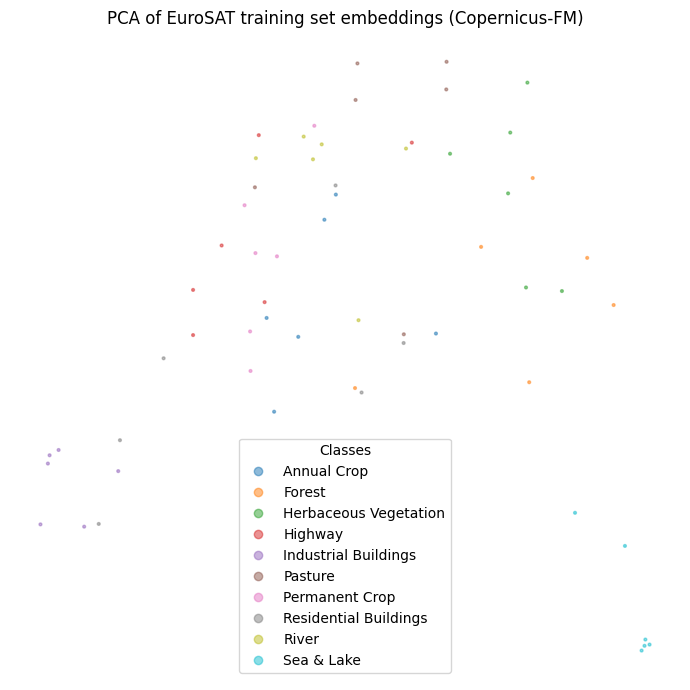

In [17]:
fig = plt.figure(figsize=(7, 7))
scatter = plt.scatter(
    x_reduced[:, 0], x_reduced[:, 1], c=y_train, cmap='tab10', s=4, alpha=0.5
)
handles, _ = scatter.legend_elements()
plt.legend(handles, class_names, title='Classes', loc='best')
plt.title('PCA of EuroSAT training set embeddings (Copernicus-FM)')
plt.axis('off')
plt.tight_layout()
plt.show()
plt.close()